<a href="https://colab.research.google.com/github/bhaweshiitk/ConformalLLM/blob/main/conformal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Resources on conformal prediction
- [A Gentle Introduction to Conformal Prediction and Distribution-Free Uncertainty Quantification
](https://arxiv.org/abs/2107.07511)
- [A tutorial on conformal prediction (video)](https://www.youtube.com/watch?v=nql000Lu_iE)


### Library imports

In [2]:
from pathlib import Path
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt; plt.style.use('default')
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
os.chdir('./drive/MyDrive/llm_probs_gpt')

FileNotFoundError: [Errno 2] No such file or directory: './drive/MyDrive/llm_probs_gpt'

In [4]:
# path to softmax scores for each subject (see repo for expected format)
data_dir = Path('./llm_probs_gpt')

In [5]:
# Load softmax scores and correct answers for each multiple choice question 
subject_names = [
    'college_computer_science', 'formal_logic', 'high_school_computer_science',
    'computer_security', 'machine_learning', 'clinical_knowledge', 
    'high_school_biology', 'anatomy', 'college_chemistry', 'college_medicine', 
    'professional_medicine', 'business_ethics', 'professional_accounting', 
    'public_relations', 'management', 'marketing',

    # --- Additional College-Level Subjects ---
    'college_biology', 
    'college_mathematics', 
    'college_physics',

    # --- Additional High School-Level Subjects ---
    'high_school_chemistry',
    'high_school_european_history',
    'high_school_geography',
    'high_school_government_and_politics',
    'high_school_macroeconomics',
    'high_school_mathematics',
    'high_school_microeconomics',
    'high_school_physics',
    #'high_school_psychology',
    #'high_school_statistics',
    #'high_school_us_history',
    #'high_school_world_history'
    
    'virology',
    'sociology',
    'philosophy',
    'logical_fallacies',
    'global_facts'
]


# datasets = {
#     'computer security': {
#         'scores': np.load(data_dir / 'computer_security_scores.npy'),
#         'targets': np.load(data_dir / 'computer_security_targets.npy'),
#     },
#     'high school computer science': {
#         'scores': np.load(data_dir / 'high_school_computer_science_scores.npy'),
#         'targets': np.load(data_dir / 'high_school_computer_science_targets.npy'),
#     },
#     'college computer science': {
#         'scores': np.load(data_dir / 'college_computer_science_scores.npy'),
#         'targets': np.load(data_dir / 'college_computer_science_targets.npy'),
#     },
#     'machine learning': {
#         'scores': np.load(data_dir / 'machine_learning_scores.npy'),
#         'targets': np.load(data_dir / 'machine_learning_targets.npy'),
#     },
#     'formal logic': {
#         'scores': np.load(data_dir / 'formal_logic_scores.npy'),
#         'targets': np.load(data_dir / 'formal_logic_targets.npy'),
#     },
#     'high school biology': {
#         'scores': np.load(data_dir / 'high_school_biology_scores.npy'),
#         'targets': np.load(data_dir / 'high_school_biology_targets.npy'),
#     },
#     'anatomy': {
#         'scores': np.load(data_dir / 'anatomy_scores.npy'),
#         'targets': np.load(data_dir / 'anatomy_targets.npy'),
#     },
#     'clinical knowledge': {
#         'scores': np.load(data_dir / 'clinical_knowledge_scores.npy'),
#         'targets': np.load(data_dir / 'clinical_knowledge_targets.npy'),
#     },
#     'college medicine': {
#         'scores': np.load(data_dir / 'college_medicine_scores.npy'),
#         'targets': np.load(data_dir / 'college_medicine_targets.npy'),
#     },
#     'professional medicine': {
#         'scores': np.load(data_dir / 'professional_medicine_scores.npy'),
#         'targets': np.load(data_dir / 'professional_medicine_targets.npy'),
#     },
#     'college chemistry': {
#         'scores': np.load(data_dir / 'college_chemistry_scores.npy'),
#         'targets': np.load(data_dir / 'college_chemistry_targets.npy'),
#     },
#     'marketing': {
#         'scores': np.load(data_dir / 'marketing_scores.npy'),
#         'targets': np.load(data_dir / 'marketing_targets.npy'),
#     },
#     'public relations': {
#         'scores': np.load(data_dir / 'public_relations_scores.npy'),
#         'targets': np.load(data_dir / 'public_relations_targets.npy'),
#     },
#     'management': {
#         'scores': np.load(data_dir / 'management_scores.npy'),
#         'targets': np.load(data_dir / 'management_targets.npy'),
#     },
#     'business ethics': {
#         'scores': np.load(data_dir / 'business_ethics_scores.npy'),
#         'targets': np.load(data_dir / 'business_ethics_targets.npy'),
#     },
#     'professional accounting': {
#         'scores': np.load(data_dir / 'professional_accounting_scores.npy'),
#         'targets': np.load(data_dir / 'professional_accounting_targets.npy'),
#     },
# }
datasets = {' '.join(name.split('_')): {'scores': np.load(data_dir / f'{name}_scores.npy'),
                                         'targets': np.load(data_dir / f'{name}_targets.npy')}
                                           for name in subject_names}

In [6]:
# Accuracy corresponding to each of the 10 GPT-4 1-shot question prompts for all 16 subjects.

dataset_accuracies = {}
for dataset, results in datasets.items():
    scores = results['scores']
    targets = results['targets']
    accuracies = []
    for score in scores:
        n = score.shape[0]
        correct = score.argmax(1) == targets
        accuracy = correct.sum() / n
        accuracies.append(accuracy)

    dataset_accuracies[dataset] = accuracies

In [7]:
# font size for the plot labels
fontsize = 24

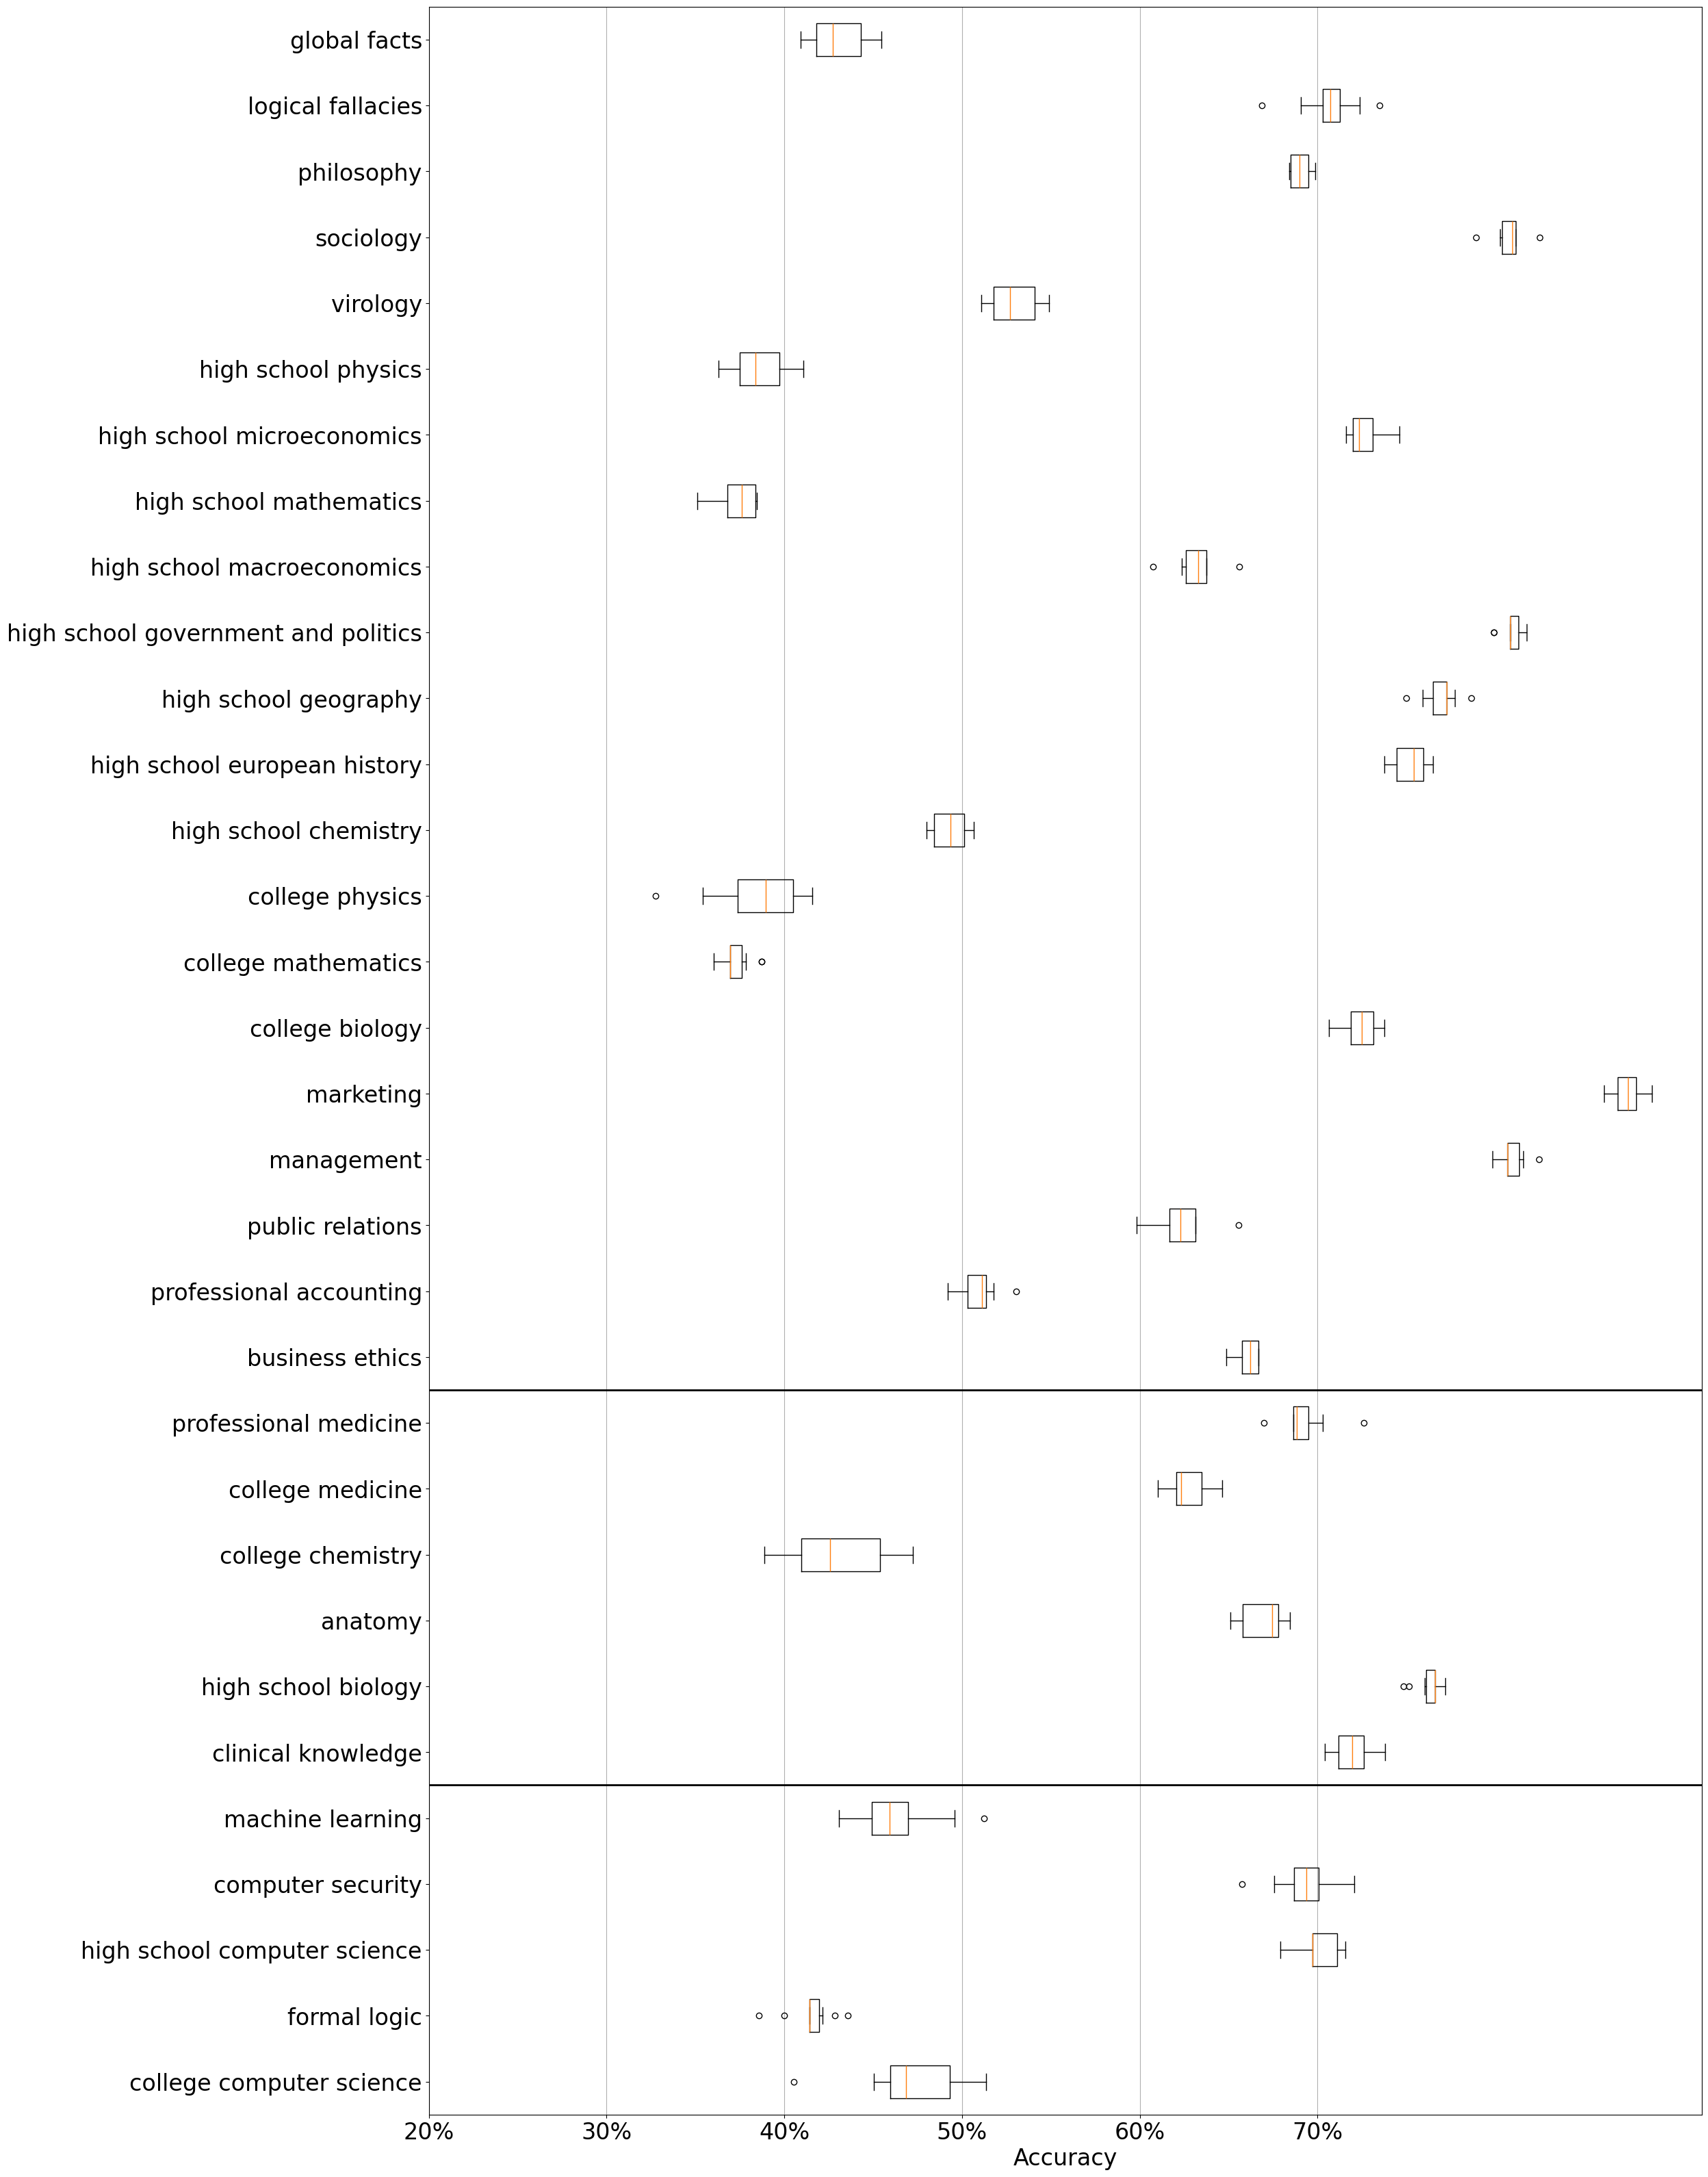

In [22]:
# Plot MCQA accuracy for each subject (accuracy can vary slightly depending on specific one-shot question used in prompt)

plt.figure(figsize=(24, 40))

bars = plt.boxplot([x for x in dataset_accuracies.values()], vert=False)
plt.axhline(11.5, ls='-', lw=2, c='k')
plt.axhline(5.5, ls='-', lw=2, c='k')
plt.xticks([0.20, 0.3, 0.40, 0.50, 0.60, 0.70], fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.gca().set_xticklabels([f'{x:.0%}' for x in plt.gca().get_xticks()])
plt.gca().set_yticklabels(dataset_accuracies.keys(), fontsize=fontsize)
plt.xlabel('Accuracy', fontsize=fontsize)
# plt.ylabel('Datasets', fontsize=fontsize)
plt.grid(ls='-', axis='x')
plt.savefig('accuracy.eps', bbox_inches='tight')
plt.show()


### Conformal prediction

- Conformal prediction consists of three steps
    1. Choosing a $\alpha$ error rate and conformal score function
    2. Estimating the $1-\alpha$ quantile of the conformal scores on the held-out dataset
    3. Using the estimated quantile to contruct prediction sets on unseen test data which satisfy marginal coverage guarantee
- $\alpha$ is the confidence level; a lower $\alpha$ corresponds to a higher desired coverage rate and will produce larger set sizes; a higher $\alpha$ allows for a larger error rate and will produce smaller prediction sets. 
- [Least Ambiguous Classifier (LAC)](https://arxiv.org/abs/1609.00451) is one popular choice of conformal score function corresponding to 1 minus the maximum softmax score that is guaranteed to have to smallest average set size. 

In [9]:
!pip install torch

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 MB 23.5 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.7 MB/s  0:00:00
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [torch]32m5/6 [torch]ools]

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [8]:
from functools import partial
import numpy as np
import torch


def calibrate_lac(scores, targets, alpha=0.1, return_dist=False):
    """
    Estimates the 1-alpha quantile on held-out calibration data.
    The score function is `1 - max(softmax_score)`.
    
    Arguments:
        scores: softmax scores of the calibration set
        targets: corresponding labels of the calibration set
        alpha: parameter for the desired coverage level (1-alpha)

    Returns:
       qhat: the estimated quantile
       score_dist: the score distribution
    """
    scores = torch.tensor(scores, dtype=torch.float)
    targets = torch.tensor(targets)
    assert scores.size(0) == targets.size(0)
    assert targets.size(0)
    n = torch.tensor(targets.size(0))
    assert n

    score_dist = torch.take_along_dim(1 - scores, targets.unsqueeze(1), 1).flatten()
    assert (
        0 <= torch.ceil((n + 1) * (1 - alpha)) / n <= 1
    ), f"{alpha=} {n=} {torch.ceil((n+1)*(1-alpha))/n=}"
    qhat = torch.quantile(
        score_dist, torch.ceil((n + 1) * (1 - alpha)) / n, interpolation="higher"
    )
    return (qhat, score_dist) if return_dist else qhat


def inference_lac(scores, qhat, allow_empty_sets=False):
    """
    Makes prediction sets on new test data
    
    Arguments:
        scores: softmax scores of the test set
        qhat: estimated quantile of the calibration set from the `calirbate_lac` function
        allow_empty_sets: if True allow a prediction set to contain no predictions (will then satisfy upper bound of marginal coverage)

    Returns:
       prediction_sets: boolean mask of prediction sets (True if class is included in the prediction set; otherwise False)
    """
    scores = torch.tensor(scores, dtype=torch.float)
    n = scores.size(0)

    elements_mask = scores >= (1 - qhat)

    if not allow_empty_sets:
        elements_mask[torch.arange(n), scores.argmax(1)] = True
        
    prediction_sets = elements_mask

    return prediction_sets



def get_coverage(psets, targets, precision=None):
    """
    Calculates empirical coverage of prediction sets
    
    Arguments:
        psets: prediction sets of test set
        targets: ground true labels of test set
        precision: rounding precision

    Returns:
       coverage: how many times the answer is in the prediction set
    """
    psets = torch.tensor(psets)
    targets = torch.tensor(targets)
    psets = psets.clone()
    targets = targets.clone()
    n = psets.shape[0]
    coverage = psets[torch.arange(n), targets].float().mean().item()
    if precision is not None:
        coverage = round(coverage, precision)
    return coverage


def get_size(psets, precision=1):
    """
    Calculates empirical set sizes of prediction sets (can consider as the average uncertainty of the model)
    
    Arguments:
        psets: prediction sets of test set
        precision: rounding precision

    Returns:
       size: how many prediction does each set contain on average
    """
    psets = psets.clone()
    size = psets.sum(1).float().mean().item()
    if precision is not None:
        size = round(size, precision)
    return size

### Experiments

In [9]:
from collections import defaultdict

alpha = 0.1  # desired error rate
num_trials = 100  # number of random trial to perform

all_q_hats = defaultdict(list)
all_scores = defaultdict(list)
all_psets = defaultdict(list)
all_targets = defaultdict(list)
other_all_coverage = defaultdict(dict)
other_all_size = defaultdict(dict)

for i in range(num_trials):
    for name, results in datasets.items():
        scores = results['scores'].mean(0)
        targets = results['targets']
        
        # shuffle data
        index = np.arange(len(scores))
        np.random.shuffle(index)

        # split data into calibration and test sets
        n = len(scores) // 2
        cal_scores = scores[index][:n]
        val_scores = scores[index][n:]
        cal_targets = targets[index][:n]
        val_targets = targets[index][n:]

        # estimate 1-alpha quantile on calibration set
        q = calibrate_lac(cal_scores, cal_targets, alpha=alpha)

        # make prediction sets on test set
        psets = inference_lac(val_scores, q)
        
        all_psets[name].append(psets)
        all_scores[name].append(val_scores)
        all_targets[name].append(val_targets)

        q_hat = q

        # do conformal on other subjects (no coverage guarantee)
        for other_name, other_results in datasets.items():
            other_scores = other_results['scores'].mean(0)
            other_targets = other_results['targets']
            
            # skip if the same subject 
            if other_scores.shape[0] == 0:
                continue

            # make prediction sets on other subject data using the same quantile estimate
            other_psets = inference_lac(other_scores, q_hat)
            if other_name not in other_all_coverage[name]:
                other_all_coverage[name][other_name] = []
                other_all_size[name][other_name] = []
            else:
                other_all_coverage[name][other_name].append(get_coverage(other_psets, other_targets))
                other_all_size[name][other_name].append(get_size(other_psets))

/var/folders/4l/5zntkz5j6k78l3ntl7k3wtp80000gn/T/ipykernel_1759/3920213444.py:75: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  psets = torch.tensor(psets)


In [12]:
print(f'COVERAGE at alpha: {alpha}')
print()
mean_coverage = np.zeros((len(other_all_coverage), len(other_all_coverage)))
for i, (first_dataset, results) in enumerate(other_all_coverage.items()):
    print(first_dataset.center(50, '-'))
    for j, (second_dataset, coverage) in enumerate(results.items()):
        if second_dataset == first_dataset:
            print(second_dataset, f'{np.mean(coverage):.0%} +/- {np.std(coverage):.0%}')
            print()
        mean_coverage[i][j] = np.mean(coverage)

print('********************')
print(f'SET SIZES at alpha: {alpha}')
print()

mean_size = np.zeros((len(other_all_size), len(other_all_size)))
for i, (first_dataset, results) in enumerate(other_all_size.items()):
    print(first_dataset.center(50, '-'))
    for j, (second_dataset, size) in enumerate(results.items()):
        if second_dataset == first_dataset:
            print(second_dataset, f'{np.mean(size):.1f} +/- {np.std(size):.1f}')
            print()
        mean_size[i][j] = np.mean(size)

COVERAGE at alpha: 0.1

-------------college computer science-------------
college computer science 94% +/- 3%

-------------------formal logic-------------------
formal logic 92% +/- 2%

-----------high school computer science-----------
high school computer science 93% +/- 3%

----------------computer security-----------------
computer security 93% +/- 2%

-----------------machine learning-----------------
machine learning 92% +/- 3%

----------------clinical knowledge----------------
clinical knowledge 91% +/- 2%

---------------high school biology----------------
high school biology 91% +/- 1%

---------------------anatomy----------------------
anatomy 92% +/- 2%

----------------college chemistry-----------------
college chemistry 93% +/- 2%

-----------------college medicine-----------------
college medicine 92% +/- 2%

--------------professional medicine---------------
professional medicine 91% +/- 2%

-----------------business ethics------------------
business ethics 93% +/- 2%

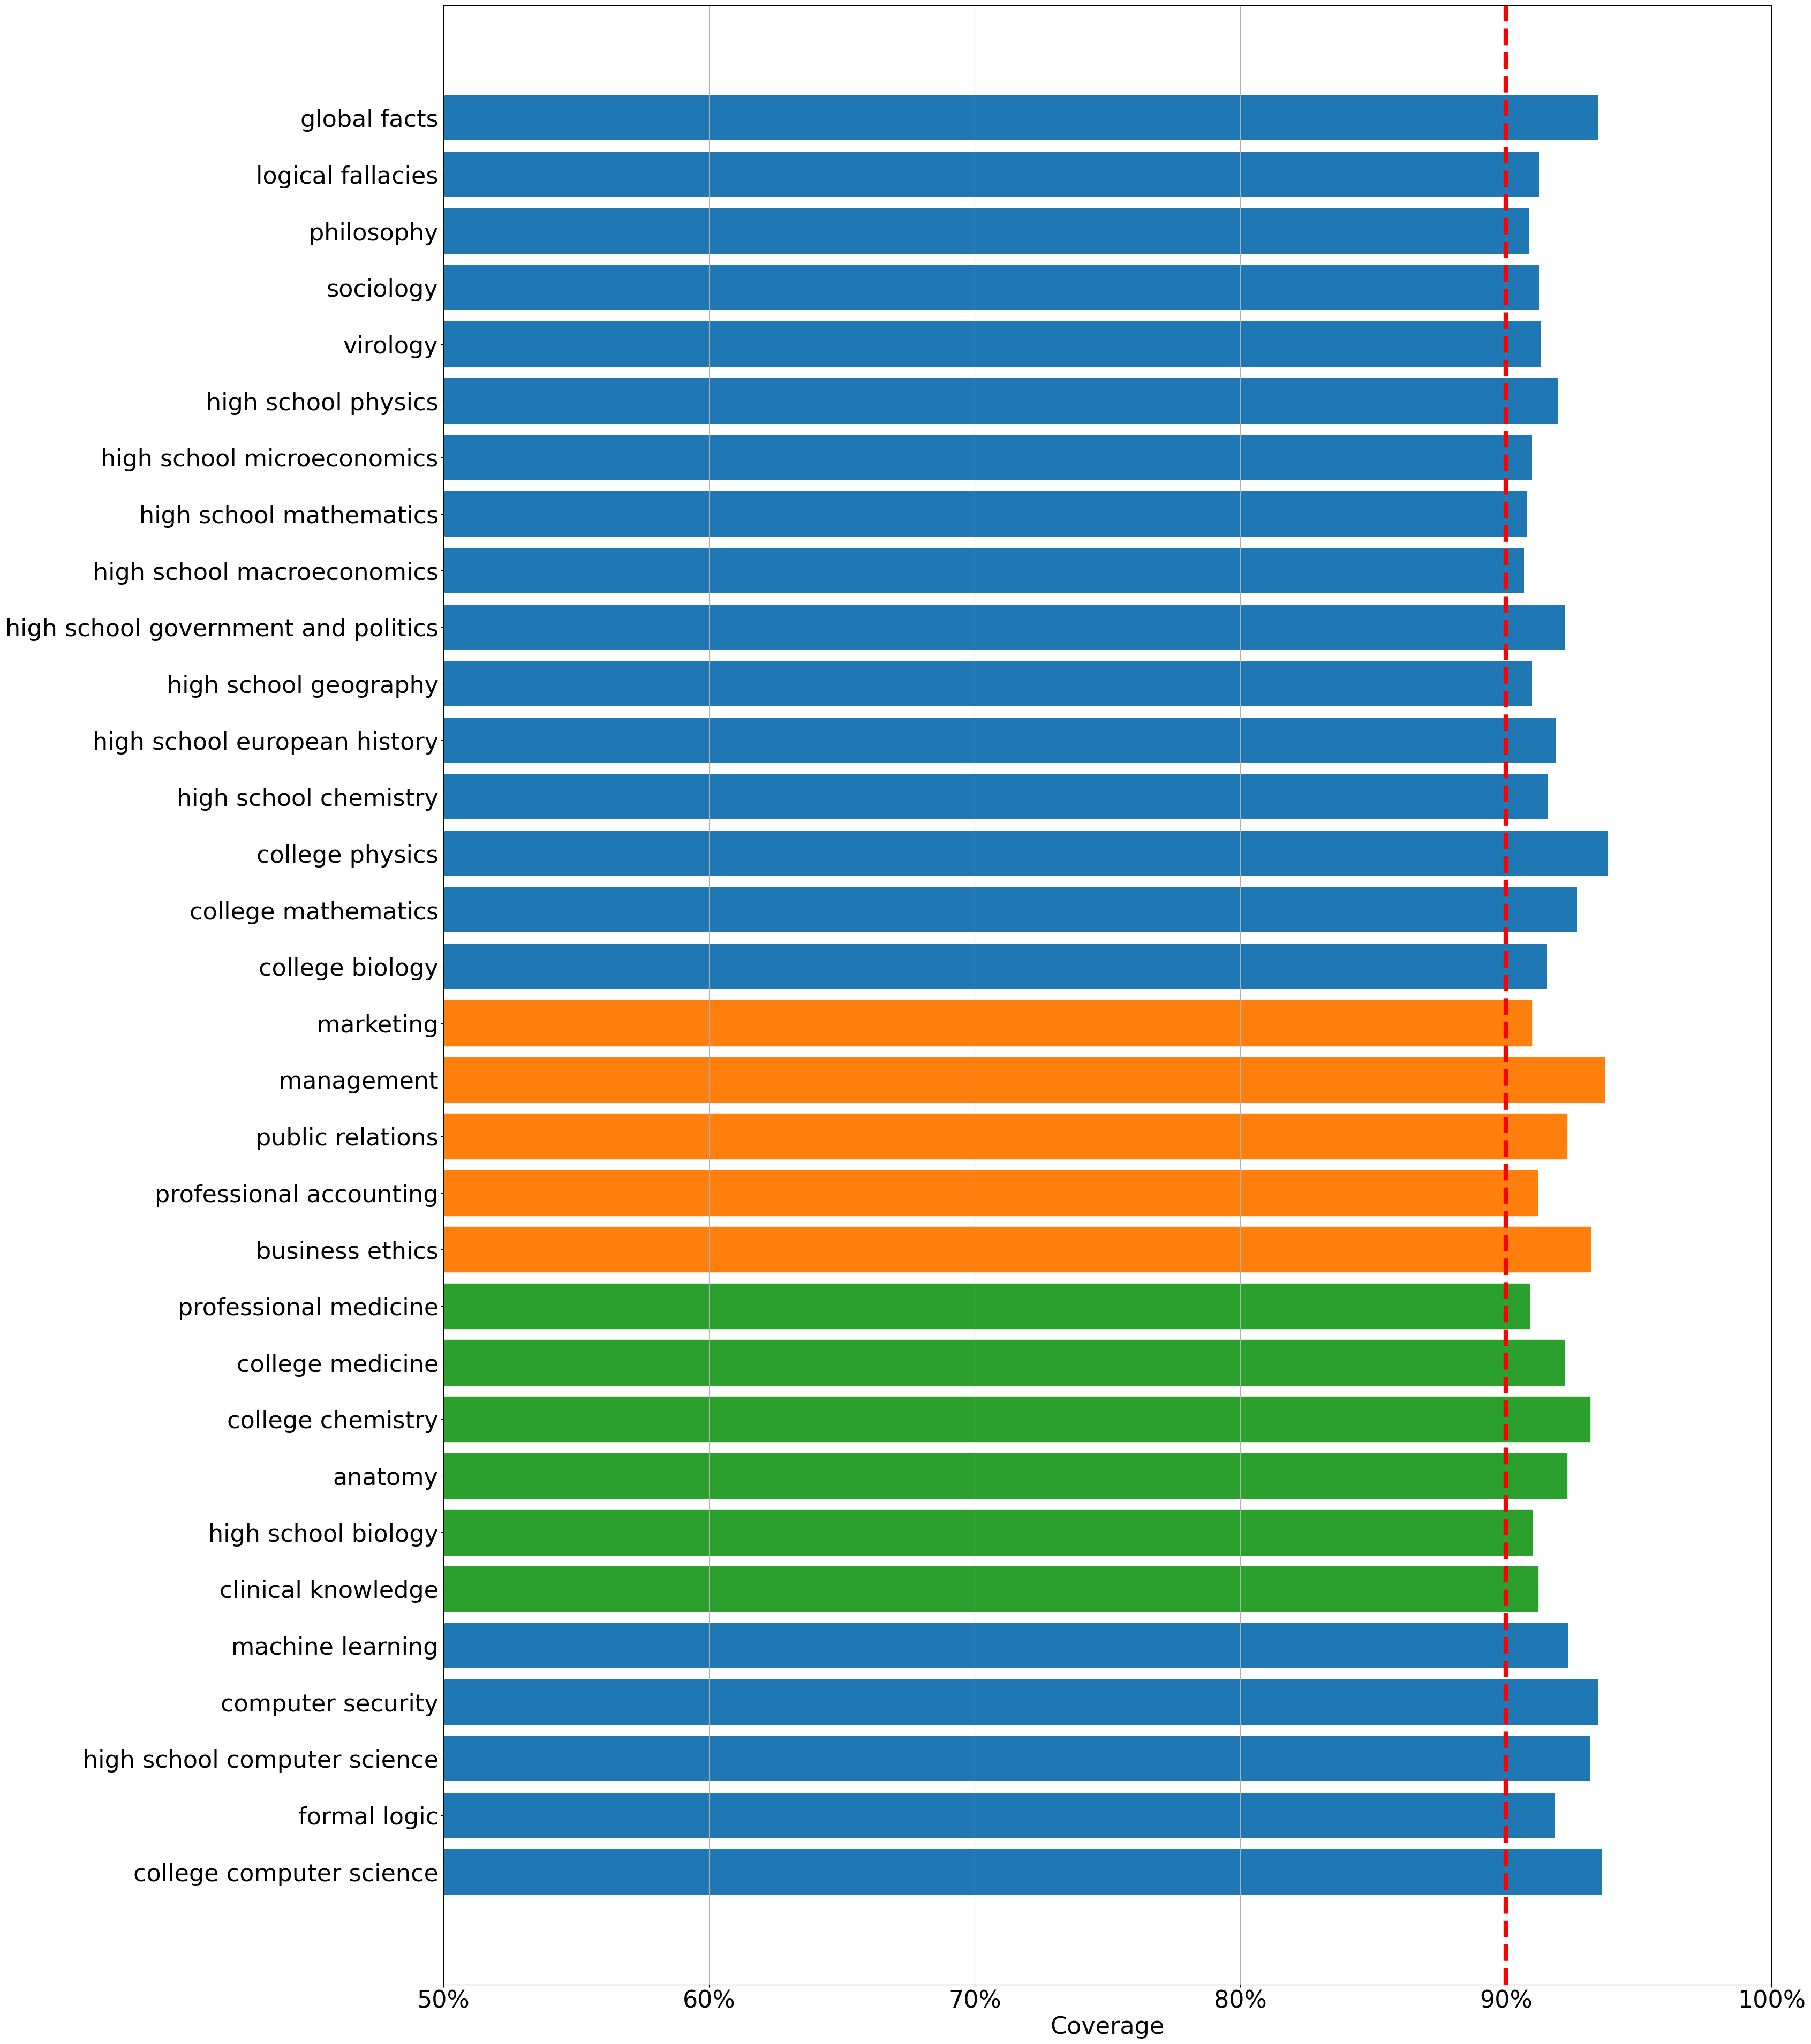

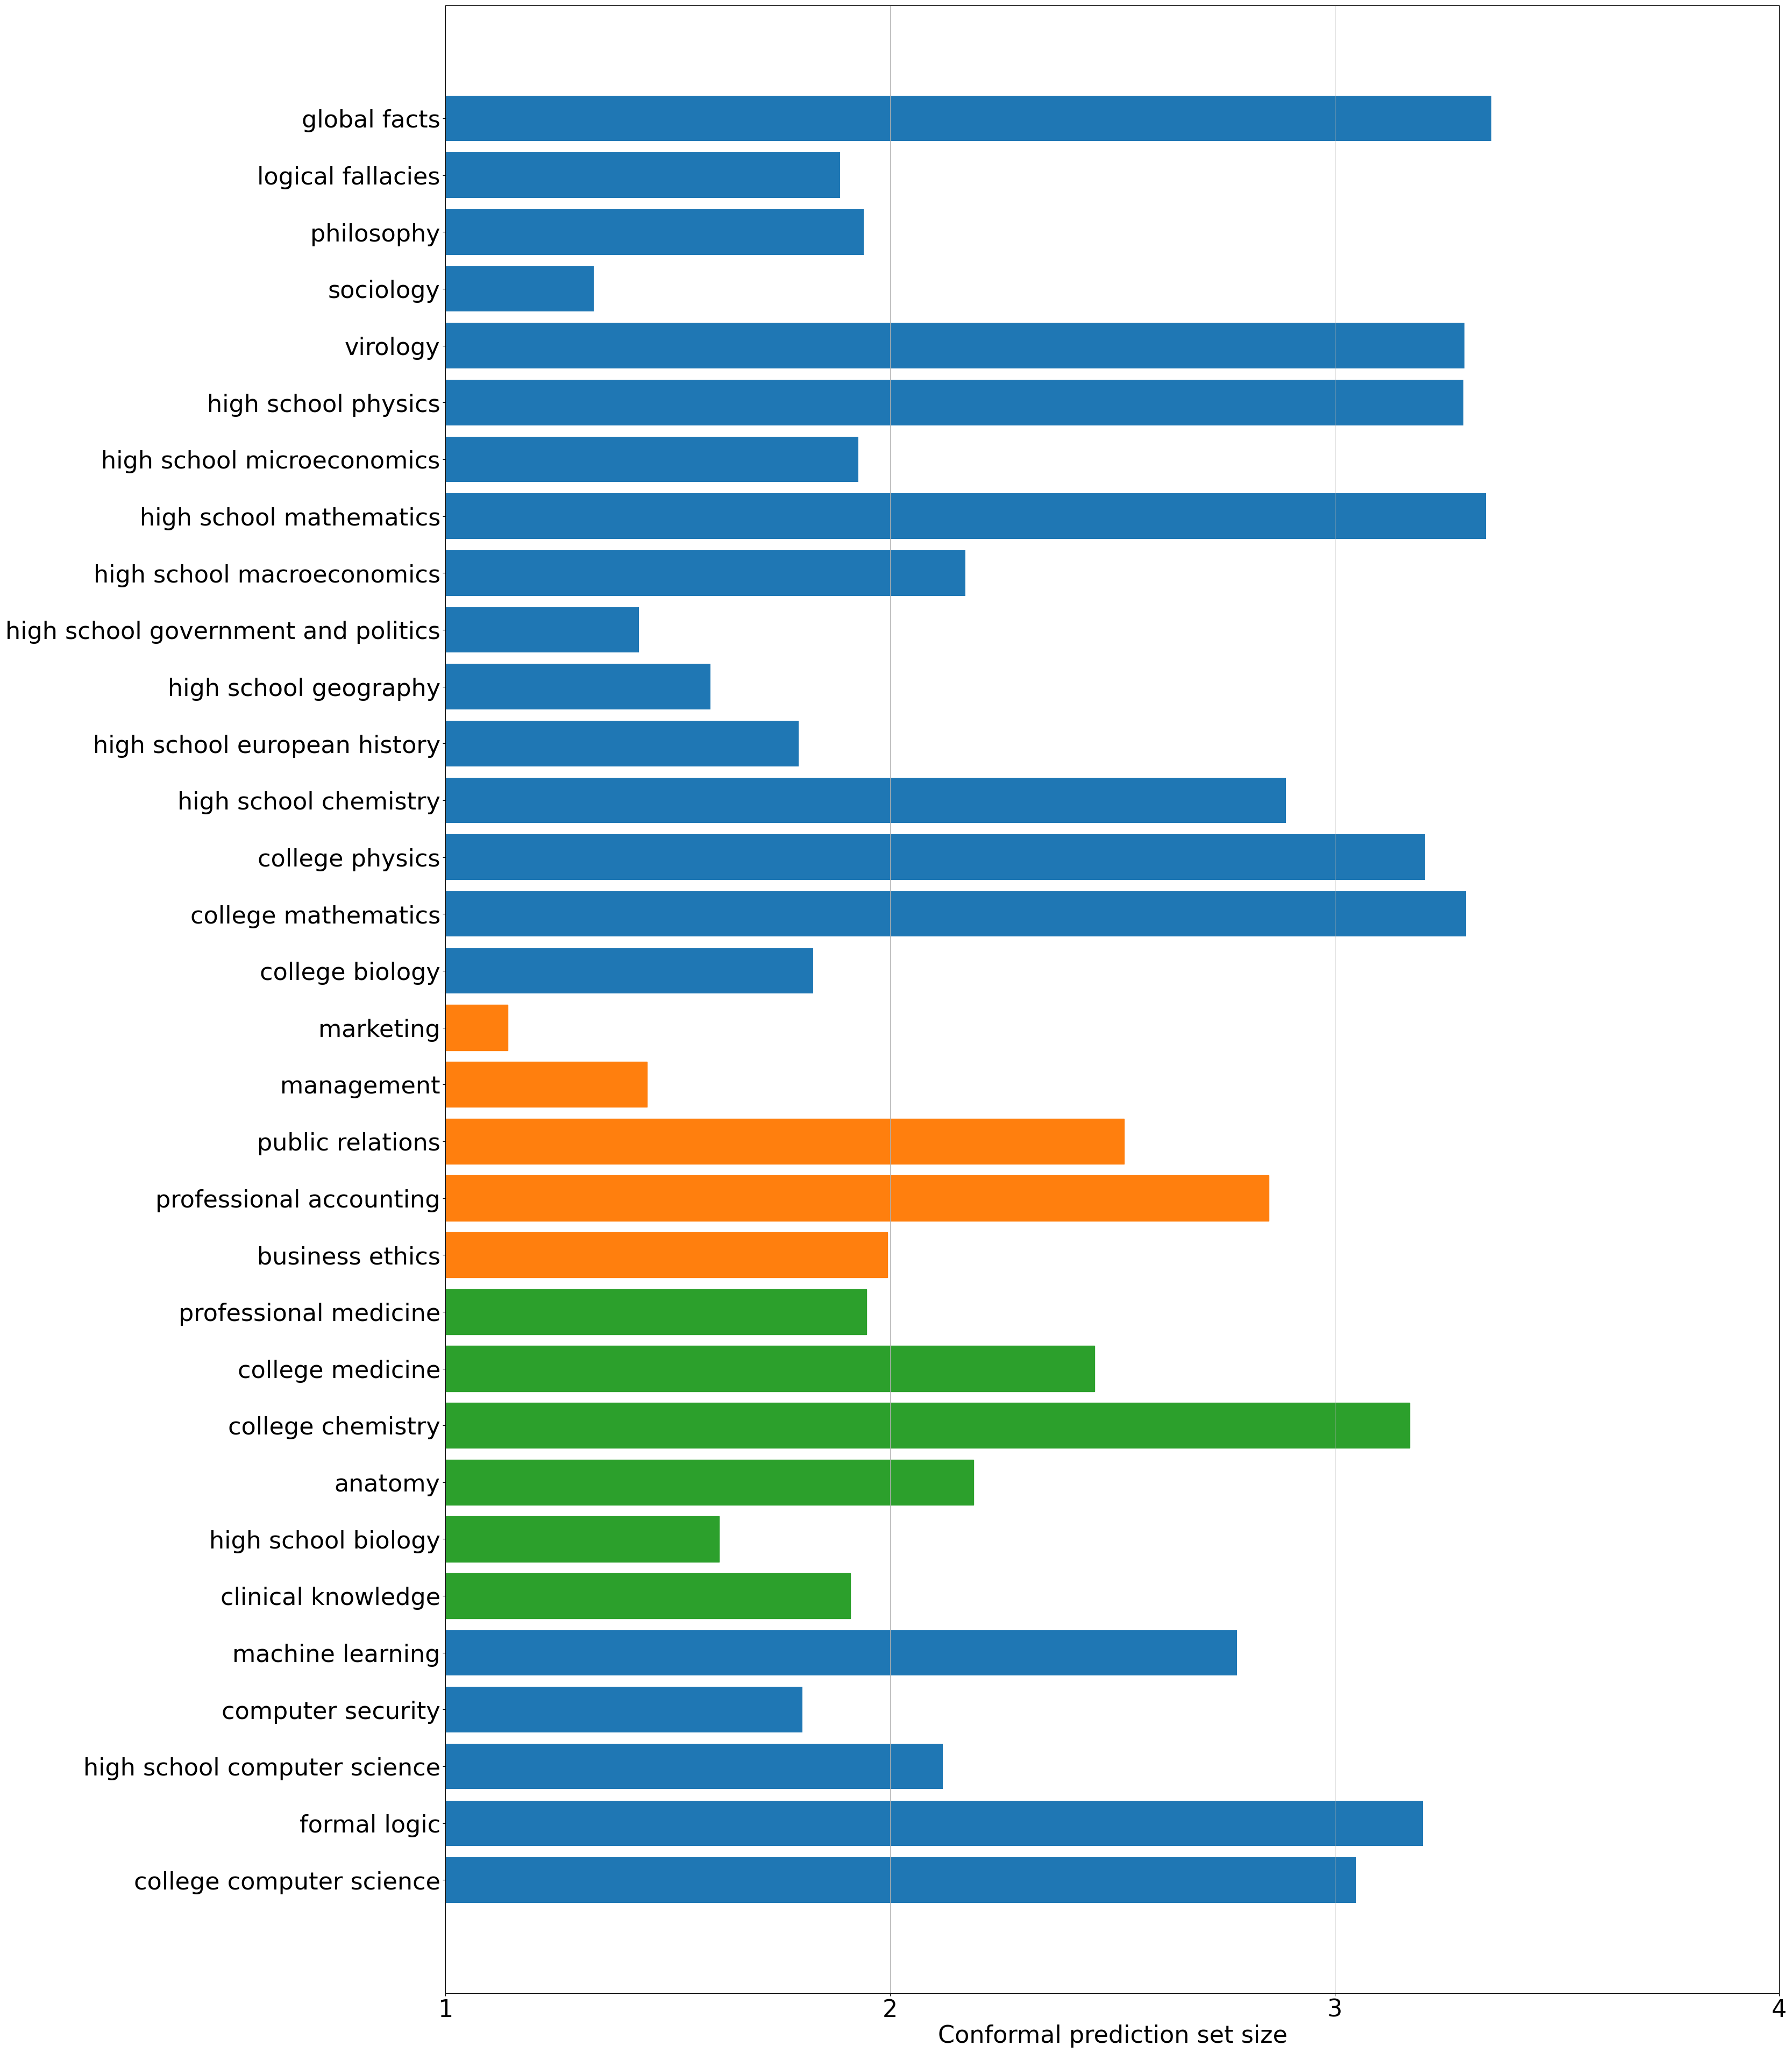

In [13]:
fontsize = 32

# plot coverage between subjects
plt.figure(figsize=(32, 48))
bars = plt.barh(list(datasets.keys()), [mean_coverage[i][i] for i in range(mean_coverage.shape[0])])
bars[5].set_color('C2')
bars[6].set_color('C2')
bars[7].set_color('C2')
bars[8].set_color('C2')
bars[9].set_color('C2')
bars[10].set_color('C2')
bars[11].set_color('C1')
bars[12].set_color('C1')
bars[13].set_color('C1')
bars[14].set_color('C1')
bars[15].set_color('C1')
# plt.axhline(10.5, ls='-', lw=2, c='k')
# plt.axhline(4.5, ls='-', lw=2, c='k')
plt.axvline(0.9, ls='--', lw=6, c='r')
plt.xlim(0.5, 1)
plt.xticks([0.5, 0.6, 0.7, 0.8, 0.9, 1], fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.gca().set_xticklabels([f'{x:.0%}' for x in plt.gca().get_xticks()])
plt.xlabel('Coverage', fontsize=fontsize)
# plt.ylabel('Datasets', fontsize=fontsize)
plt.grid(ls='-', axis='x')
plt.savefig('coverage.eps', bbox_inches='tight')
plt.show()

# plot set size between subjects
plt.figure(figsize=(32, 48))
bars = plt.barh(list(datasets.keys()), [mean_size[i][i] for i in range(mean_size.shape[0])])
bars[5].set_color('C2')
bars[6].set_color('C2')
bars[7].set_color('C2')
bars[8].set_color('C2')
bars[9].set_color('C2')
bars[10].set_color('C2')
bars[11].set_color('C1')
bars[12].set_color('C1')
bars[13].set_color('C1')
bars[14].set_color('C1')
bars[15].set_color('C1')
plt.xlim(1, 4)
# plt.axvline(0.8, ls='--', lw=6, c='r')
# plt.axhline(10.5, ls='-', lw=2, c='k')
# plt.axhline(4.5, ls='-', lw=2, c='k')
plt.xticks([1, 2, 3, 4], fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.xlabel('Conformal prediction set size', fontsize=fontsize)
# plt.ylabel('Datasets', fontsize=fontsize)
plt.grid(ls='-', axis='x')
plt.savefig('size.eps', bbox_inches='tight')
plt.show()

In [14]:
names = list(datasets.keys())

/var/folders/4l/5zntkz5j6k78l3ntl7k3wtp80000gn/T/ipykernel_1759/1653089619.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels([f'{x:.1%}' for x in cbar.ax.get_yticks()])


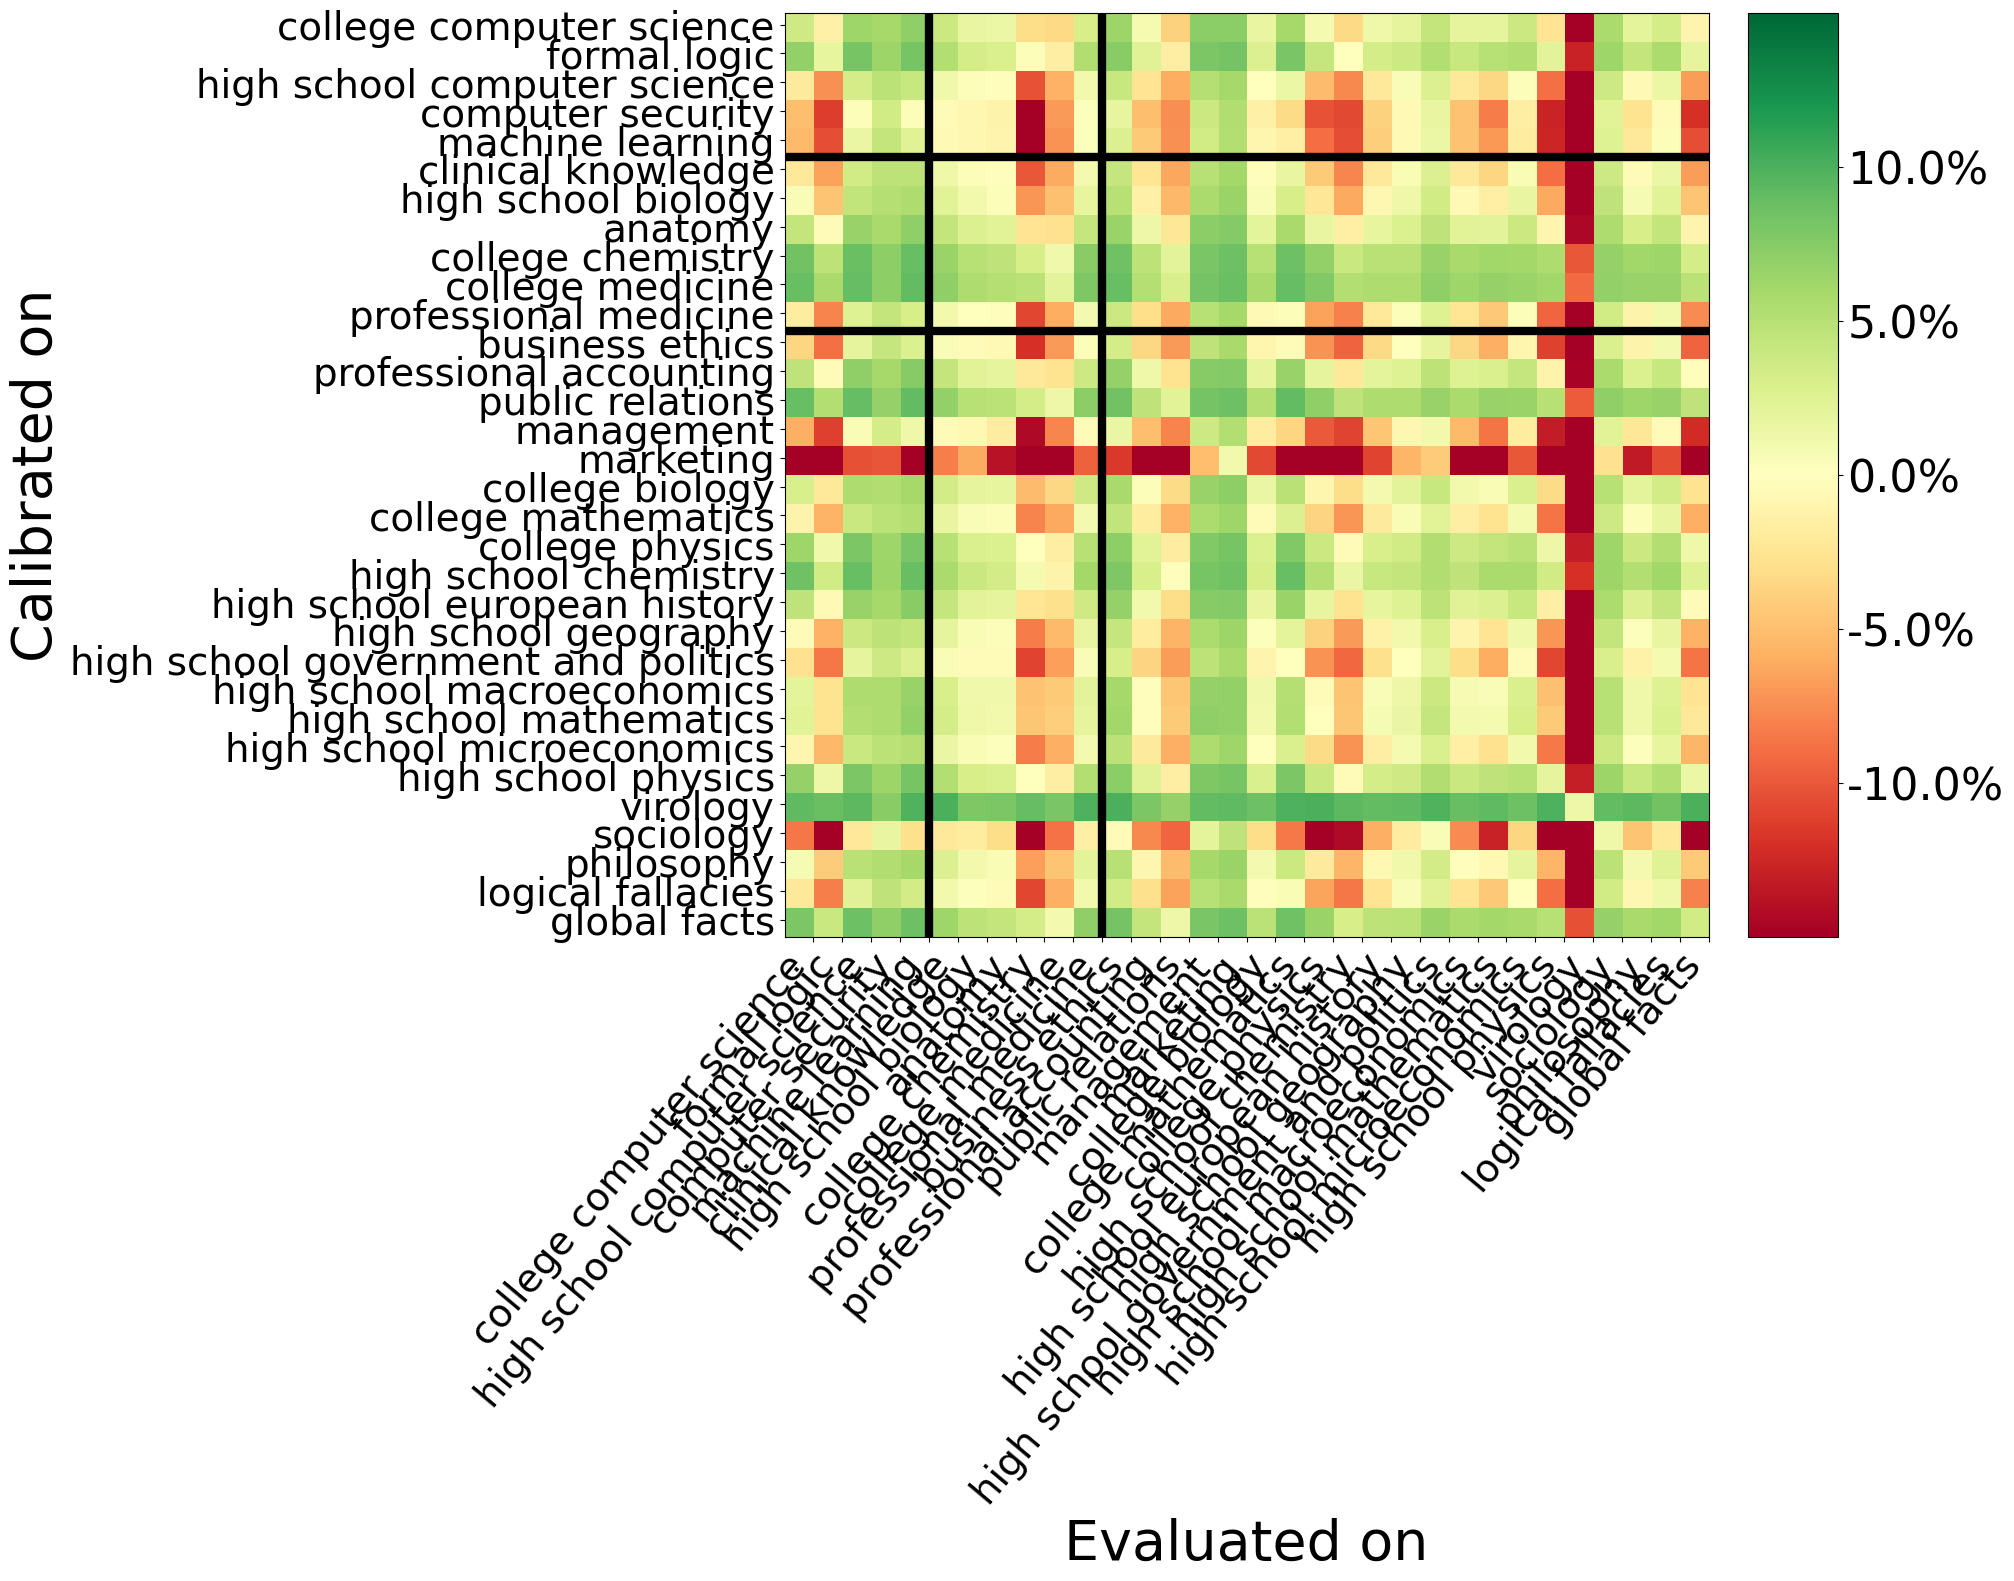

In [17]:
import matplotlib.colors as mcolors
# plot deviation from desired coverage when calibrating quantile on out of subject MCQA data
plt.figure(figsize=(12, 12))
plt.grid(False)
plt.imshow(
    mean_coverage - (1-alpha),
    # cmap=plt.get_cmap('seismic'),
    cmap=plt.get_cmap('RdYlGn'),
    norm = mcolors.TwoSlopeNorm(vmin=-0.15, vcenter=0.0, vmax=0.15)
)
plt.xticks(np.arange(len(names)) + 0.5, names, fontsize=fontsize-4, rotation=50, ha='right', va='top')
plt.yticks(np.arange(len(names)) - 0.1, names, fontsize=fontsize-4)
plt.xlabel('Evaluated on', fontsize=fontsize+8)
plt.ylabel('Calibrated on', fontsize=fontsize+8)
plt.axhline(10.5, ls='-', lw=6, c='k')
plt.axhline(4.5,  ls='-', lw=6, c='k')
plt.axvline(10.5, ls='-', lw=6, c='k')
plt.axvline(4.5,  ls='-', lw=6, c='k')

cax = plt.axes([0.93, 0.11, 0.075, 0.77])
cbar = plt.colorbar(cax=cax)
cbar.ax.tick_params(labelsize=fontsize)
cbar.ax.set_yticklabels([f'{x:.1%}' for x in cbar.ax.get_yticks()])
# plt.tick_params('x')
plt.savefig(f'calibration-{alpha}.png', bbox_inches='tight')
plt.show()

In [22]:
def get_accuracy(scores, targets):
    n = len(scores)
    if n == 0:
        return 0.0
    correct = (scores.argmax(1) == targets).sum()
    accuracy = correct / n

    return accuracy

acc_results = {}
cov_results = {}
for dataset in datasets.keys():
    stratified_coverage = defaultdict(list)
    stratified_accuracy = defaultdict(list)
    stratified_count = defaultdict(list)
    for k in range(1, 5):
        for i, psets in enumerate(all_psets[dataset]):
            mask = psets.sum(1) == k
            psets = psets[mask]
            scores = all_scores[dataset][i][mask]
            stratified_coverage[k].append(get_coverage(psets, all_targets[dataset][i][mask]))
            stratified_accuracy[k].append(get_accuracy(scores, all_targets[dataset][i][mask]))

    # plt.plot(stratified_coverage.keys(), stratified_coverage.values(), label=dataset)
    acc_results[dataset] = dict(stratified_accuracy)
    cov_results[dataset] = dict(stratified_coverage)
    # cnt_results[dataset] = stratified_count


/var/folders/4l/5zntkz5j6k78l3ntl7k3wtp80000gn/T/ipykernel_1759/3920213444.py:75: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  psets = torch.tensor(psets)


In [29]:
print(acc[0])

KeyError: 0

### How often is the model right at a specific prediction set size (model uncertainty)

We expect the model to be right more often when it is more confident (small prediction sets) and wrong when the prediction sets are large.

41


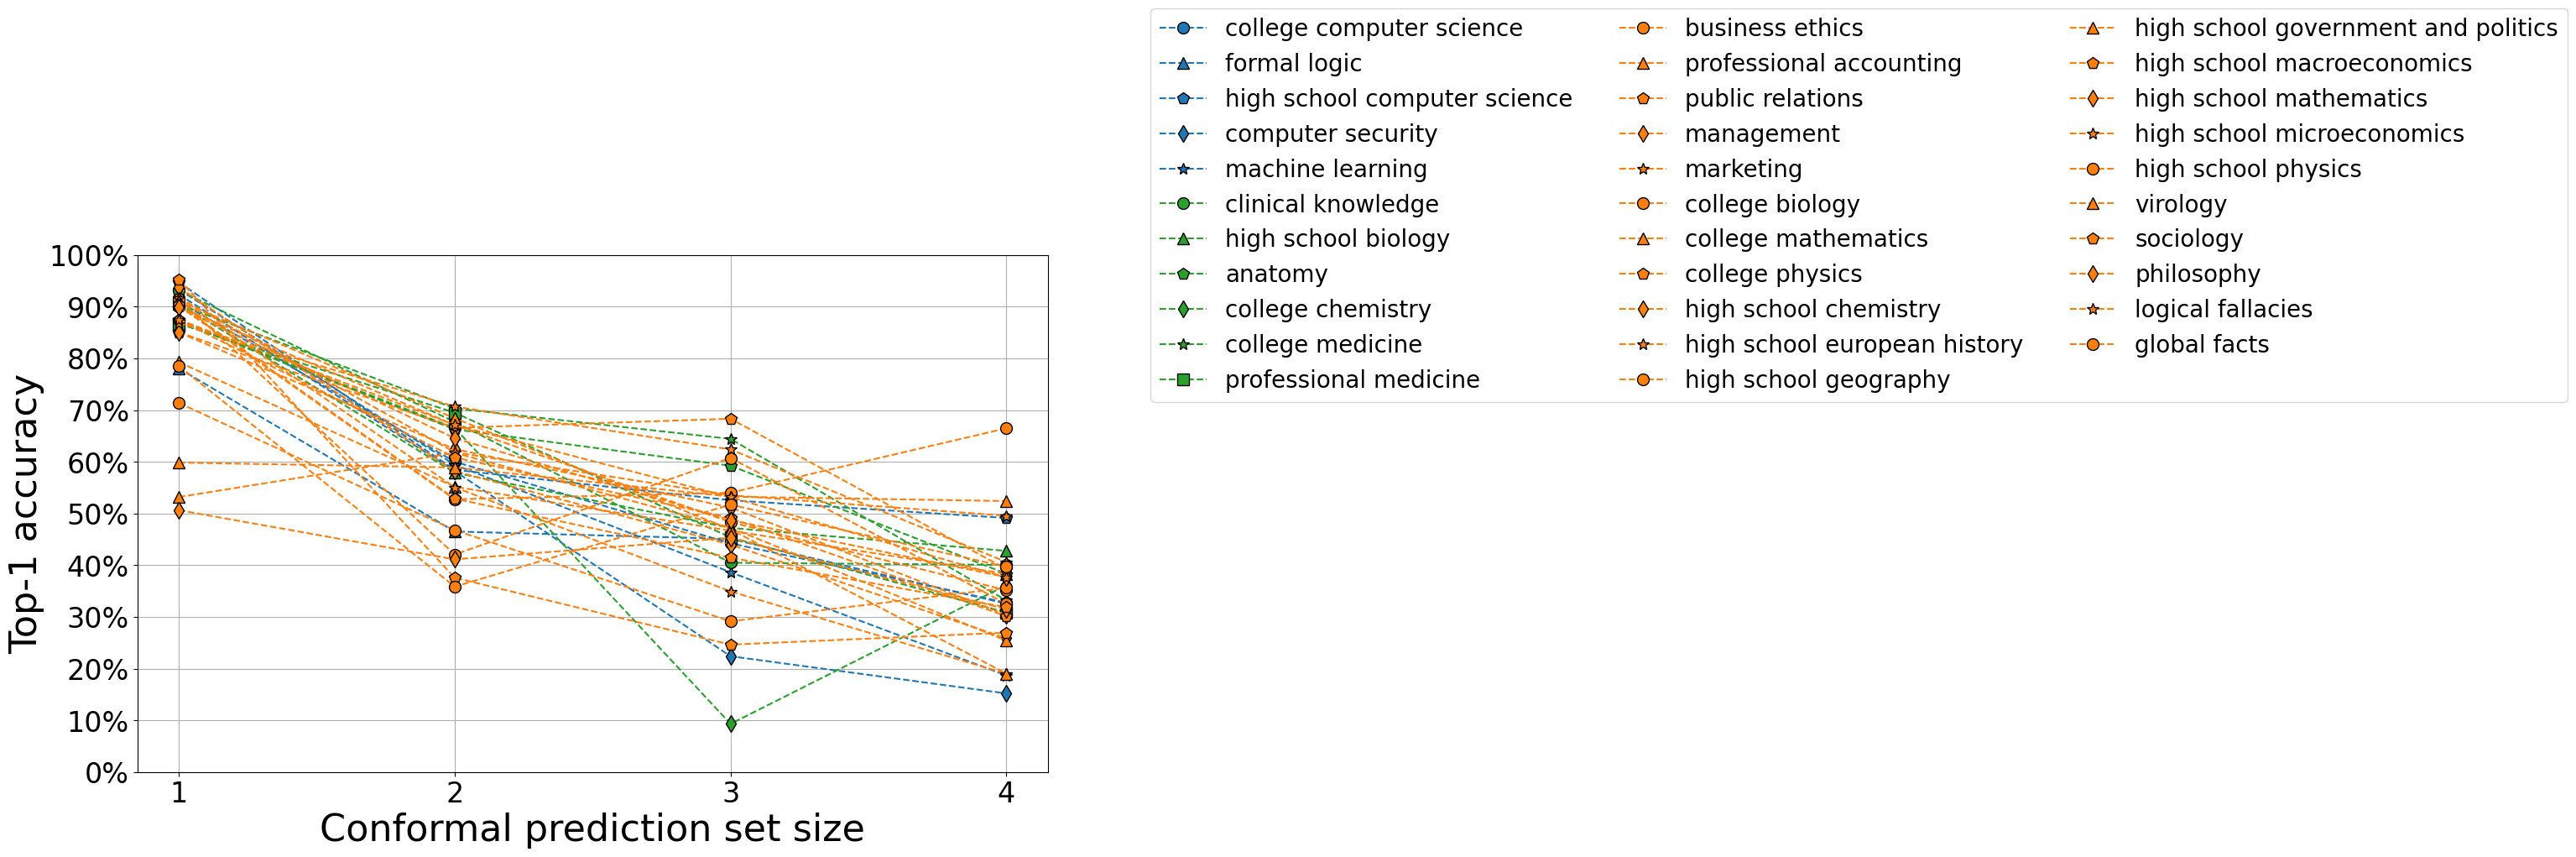

In [35]:
fontsize = 24
plt.figure(figsize=(14, 8))

markers = ['o', '^', 'p', 'd', '*'] + ['o', '^', 'p', 'd', '*', 's'] + ['o', '^', 'p', 'd', '*']*6
print(len(markers))
for i, (dataset, acc) in enumerate(acc_results.items()):
    if dataset in names[:5]:
        c = 'C0'
    elif dataset in names[5:11]:
        c = 'C2'
    elif dataset in names[10:]:
        c = 'C1'
    plt.plot(acc.keys(), [np.mean(x) for x in acc.values()], label=dataset, ls='--', marker=markers[i], markersize=10, c=c, markeredgecolor='k')

plt.legend(fontsize=fontsize-4, bbox_to_anchor=(1.1, 1.50), ncol=3)
plt.xticks([1, 2, 3, 4], fontsize=fontsize)
plt.yticks(np.arange(0.0, 1.1, 0.1), fontsize=fontsize)
plt.gca().set_yticklabels([f'{x:.0%}' for x in plt.gca().get_yticks()])
plt.xlabel('Conformal prediction set size', fontsize=fontsize+8)
plt.ylabel('Top-1 accuracy', fontsize=fontsize+8)
plt.grid(True,)
plt.savefig('selective-accuracy.png', bbox_inches='tight')
plt.show()

### What percent of the time is the true answer one of the predicted answers in the prediction set?

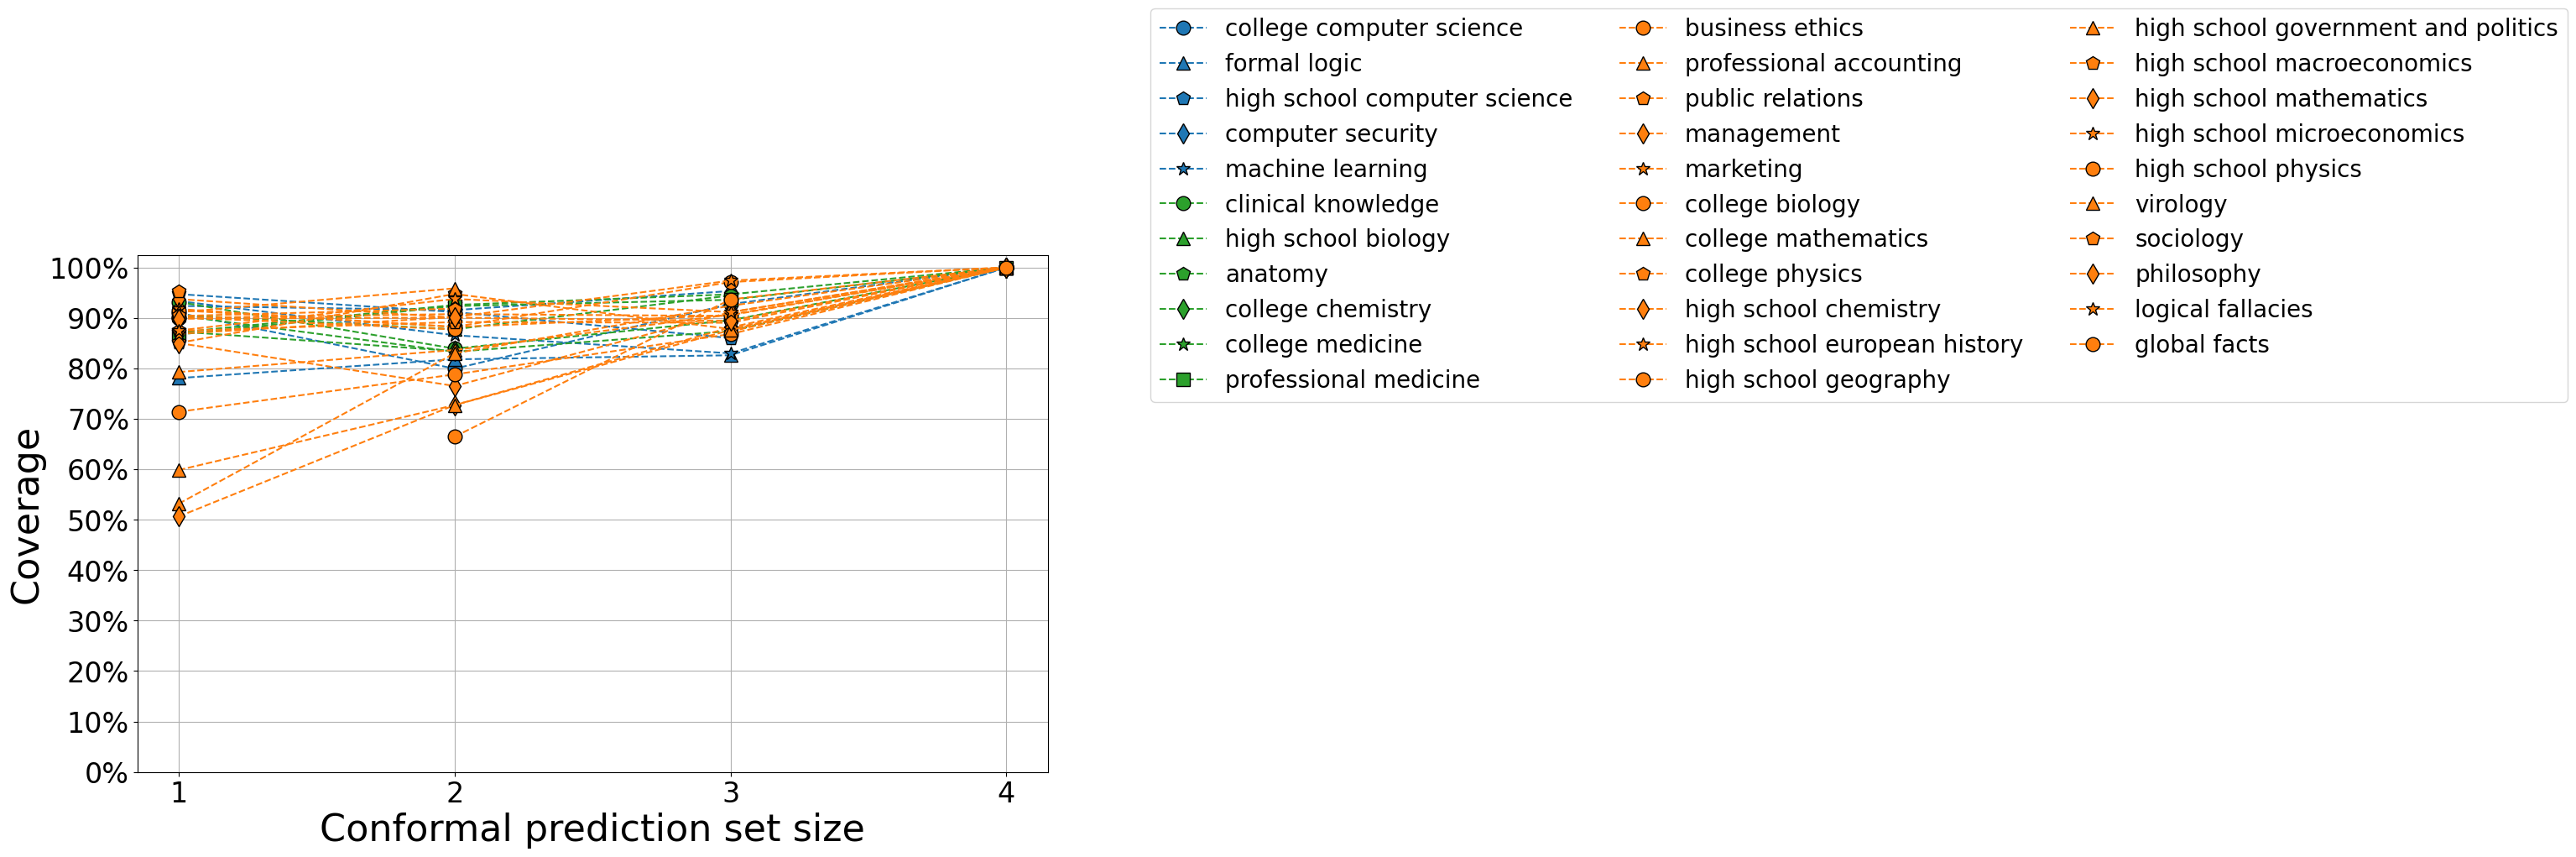

In [36]:
fontsize = 24
plt.figure(figsize=(14, 8))

for i, (dataset, acc) in enumerate(cov_results.items()):
    if dataset in names[:5]:
        c = 'C0'
    elif dataset in names[5:11]:
        c = 'C2'
    elif dataset in names[10:]:
        c = 'C1'
    plt.plot(acc.keys(), [np.mean(x) for x in acc.values()], label=dataset, ls='--', marker=markers[i], markersize=12, c=c, markeredgecolor='k')

plt.legend(fontsize=fontsize-4, bbox_to_anchor=(1.1, 1.50), ncol=3)
plt.xticks([1, 2, 3, 4], fontsize=fontsize)
plt.yticks(np.arange(0, 1.1, 0.1), fontsize=fontsize)
plt.gca().set_yticklabels([f'{x:.0%}' for x in plt.gca().get_yticks()])
plt.xlabel('Conformal prediction set size', fontsize=fontsize+8)
plt.ylabel('Coverage', fontsize=fontsize+8)
plt.grid(True,)
plt.savefig('stratified-coverage.png', bbox_inches='tight')
plt.show()

### How does conformal compare to just always taking the "top-k" highest softmax scores?

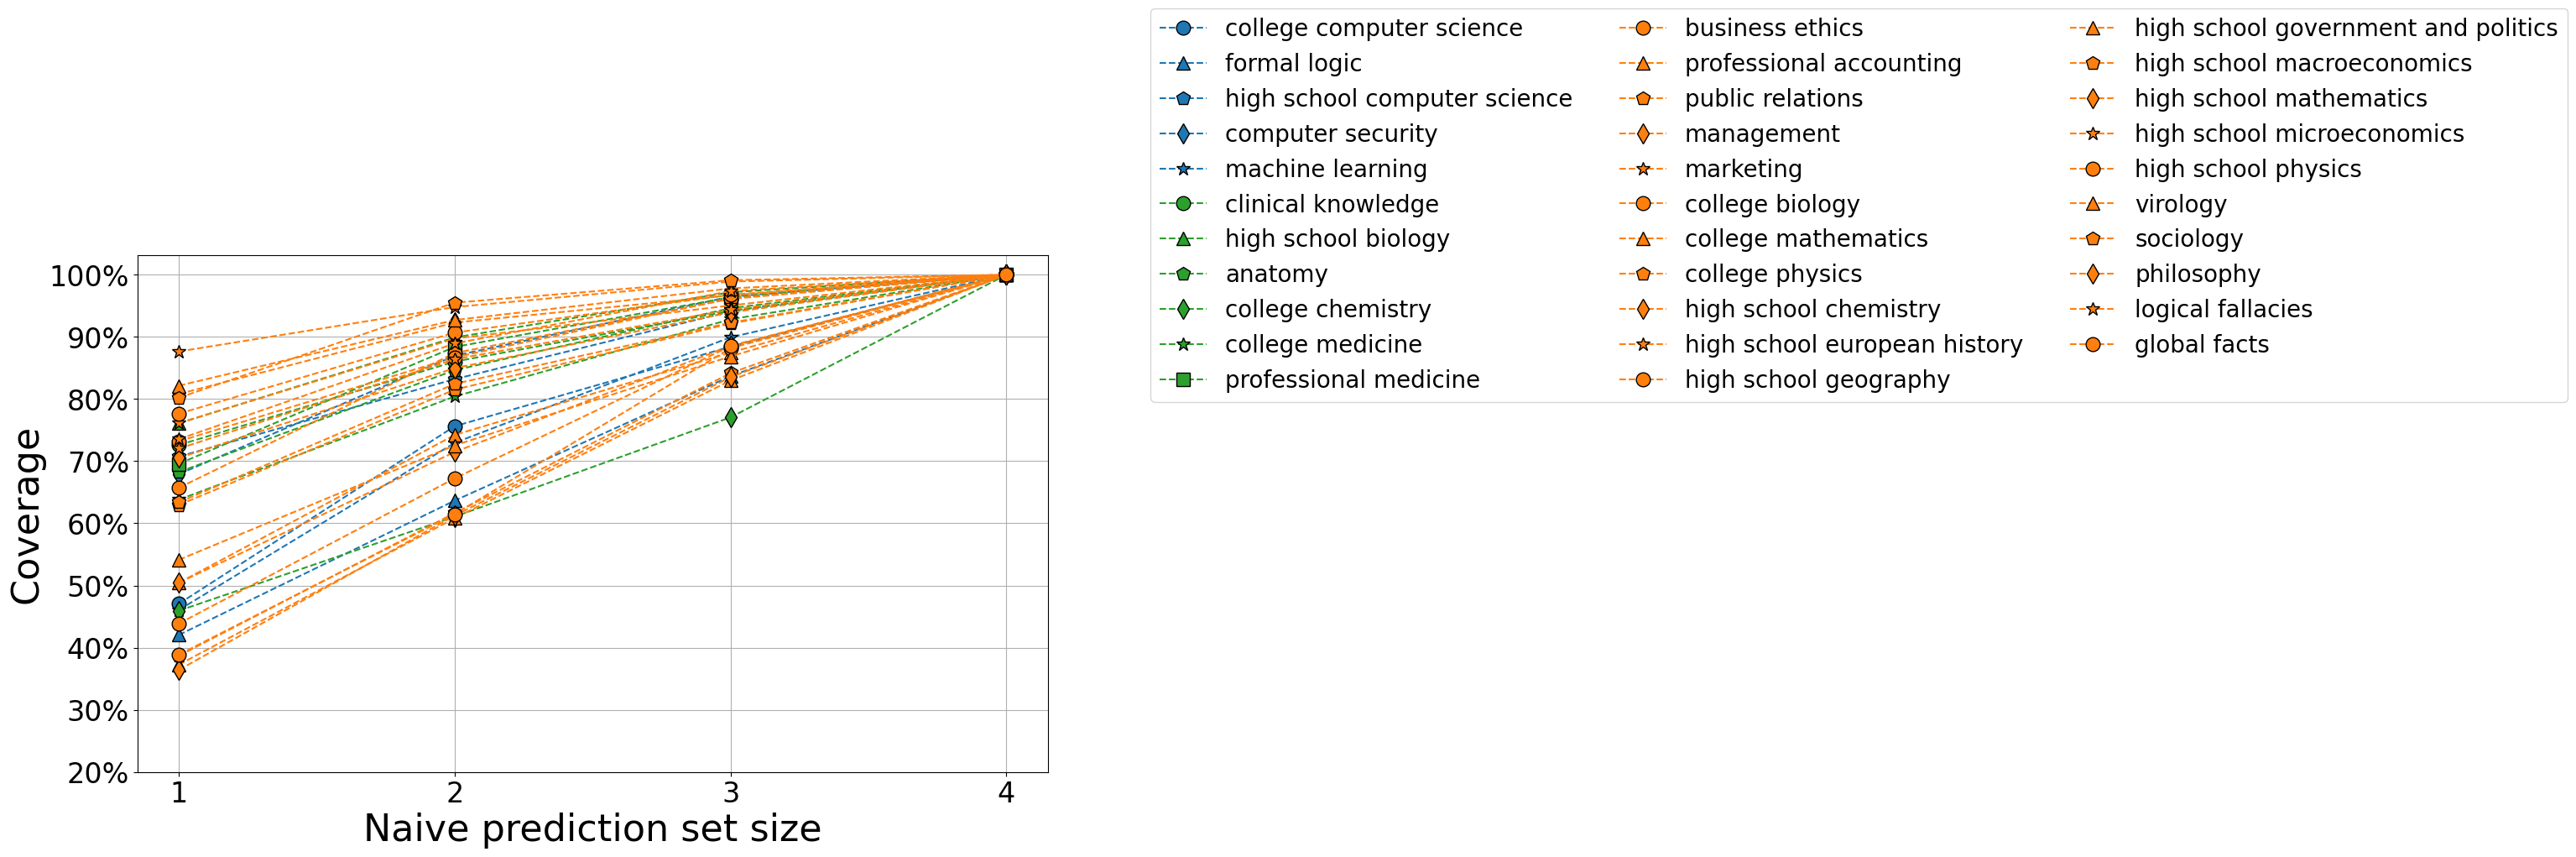

In [37]:
naive_results = {}
for dataset in datasets.keys():
    naive_coverage = defaultdict(list)
    for k in range(1, 5):
        for i, scores in enumerate(all_scores[dataset]):
            sorted_scores = np.flip(scores.argsort(), 1)[:, :k]
            psets = np.eye(4)[sorted_scores].sum(1)
            naive_coverage[k].append(get_coverage(psets.copy(), all_targets[dataset][i]))

    naive_results[dataset] = dict(naive_coverage)

fontsize = 24
plt.figure(figsize=(14, 8))

for i, (dataset, acc) in enumerate(naive_results.items()):
    if dataset in names[:5]:
        c = 'C0'
    elif dataset in names[5:11]:
        c = 'C2'
    elif dataset in names[10:]:
        c = 'C1'
    plt.plot(acc.keys(), [np.mean(x) for x in acc.values()], label=dataset, ls='--', marker=markers[i], markersize=12, c=c, markeredgecolor='k')

plt.legend(fontsize=fontsize-4, bbox_to_anchor=(1.1, 1.50), ncol=3)
plt.xticks([1, 2, 3, 4], fontsize=fontsize)
plt.yticks(np.arange(0.2, 1.1, 0.1), fontsize=fontsize)
plt.gca().set_yticklabels([f'{x:.0%}' for x in plt.gca().get_yticks()])
plt.xlabel('Naive prediction set size', fontsize=fontsize+8)
plt.ylabel('Coverage', fontsize=fontsize+8)
plt.grid(True,)
plt.savefig('navie-coverage.png', bbox_inches='tight')
plt.show()

### Comparing accuracy using real (MMLU) vs generated (GPT-4) question-answer examples in the prompt template

In [21]:
import pickle

In [34]:
with open('../../../accuracy_gpt_prompts_10.pkl', 'rb') as f:
    gpt_acc = pickle.load(f)

with open('../../../accuracy_mmlu_prompts_10.pkl', 'rb') as f:
    mmlu_acc = pickle.load(f)

FileNotFoundError: [Errno 2] No such file or directory: '../../../accuracy_gpt_prompts_10.pkl'

<ipython-input-24-67924fe3cabe>:21: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_xticklabels([f'{x:.0%}' for x in plt.gca().get_xticks()], fontsize=fontsize-4)


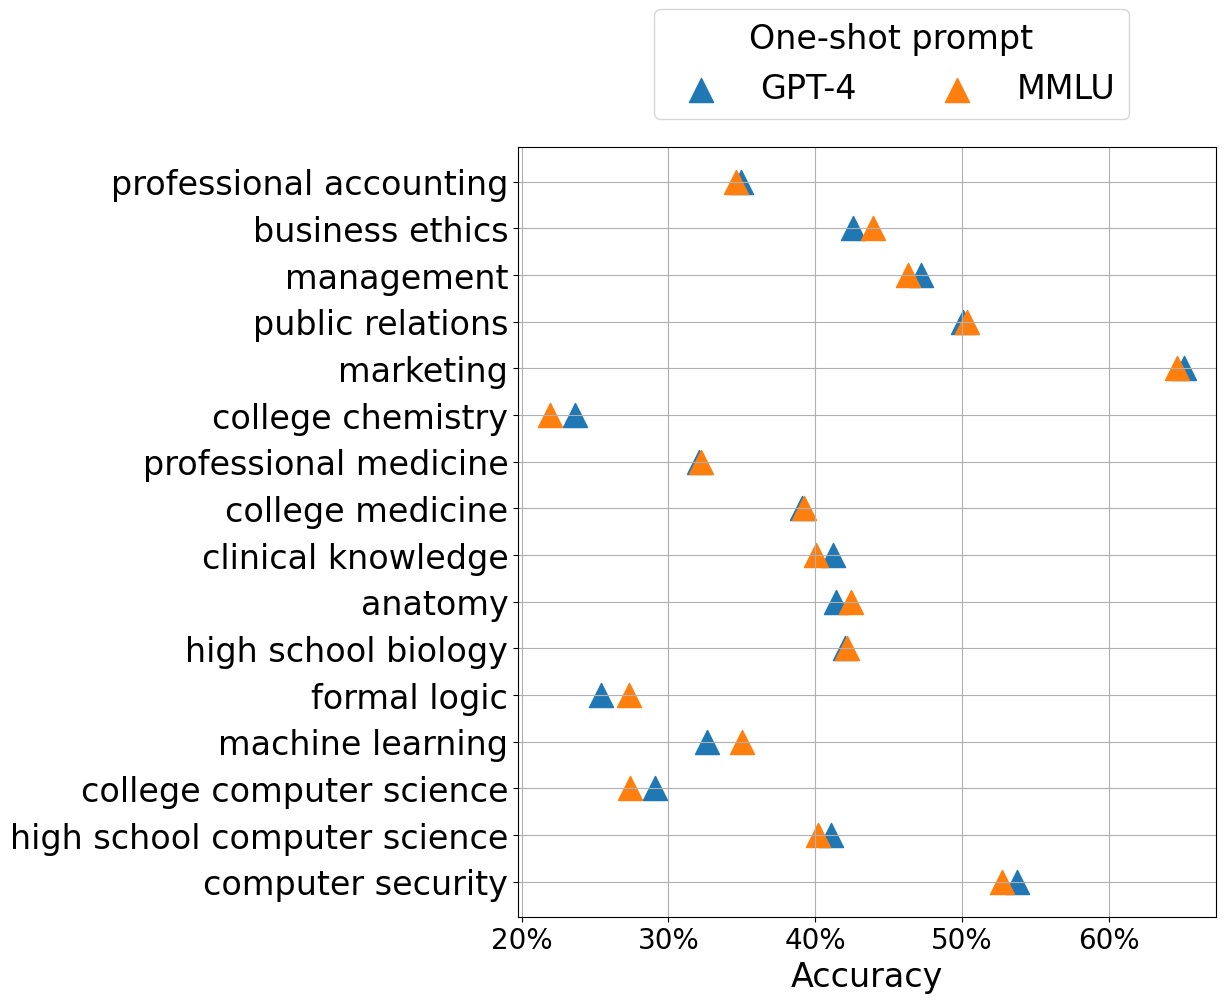

In [24]:
plt.figure(figsize=(9, 10))
names = []
counter = 0
for name in datasets.keys():
    dataset = name.replace(' ', '_')
    if dataset in gpt_acc and dataset in mmlu_acc:
        names.append(name)
        if counter == 0:
            gpt_label = 'GPT-4'
            mmlu_label = 'MMLU'
        else:
            gpt_label = None
            mmlu_label = None
        plt.scatter(np.mean(gpt_acc[dataset]), counter, label=gpt_label, c='C0', s=300, marker='^')
        plt.scatter(np.mean(mmlu_acc[dataset]), counter, label=mmlu_label, c='C1', s=300, marker='^')
        counter += 1

# plt.axhline(11.5, ls='-', lw=2, c='k')
# plt.axhline(5.5, ls='-', lw=2, c='k')
plt.yticks(range(len(names)), fontsize=12)
plt.gca().set_xticklabels([f'{x:.0%}' for x in plt.gca().get_xticks()], fontsize=fontsize-4)
plt.gca().set_yticklabels(names, fontsize=fontsize)
plt.xlabel('Accuracy', fontsize=fontsize)
# plt.ylabel('Datasets', fontsize=fontsize)
plt.grid(ls='-', axis='both')
plt.legend(fontsize=fontsize, title='One-shot prompt', title_fontsize=fontsize, bbox_to_anchor=(0.9, 1.20), ncol=2)
plt.savefig('gpt-vs-mmlu.eps', bbox_inches='tight')
plt.show()